<div style="
    background: linear-gradient(to right,rgb(246, 37, 156),rgb(175, 56, 244));
    padding: 5px;
    border-radius: 8px;
    box-shadow: 2px 2px 8px rgb(255, 255, 255);
">
  <h3 style="
      color: Black;
      font-size: 18px;
      font-weight: 800;
      font-family: 'Segoe UI', sans-serif;
      margin: 0;
  ">Load Libraries</h3>
</div>

In [1]:
# Loading the initial required libraries
import sys
import os
import pandas as pd # Data handling and manipulation
import numpy as np # Numerical computations
import matplotlib.pyplot as plt # General plotting
import itertools
import seaborn as sns # Statistical visualizations
import sklearn #Machine Learning and Model Evaluation
import scipy.stats as stats
import gradio as gr
import joblib
import tensorflow as tf

from sklearn.model_selection import train_test_split # to split the dataset for training and testing
from sklearn.model_selection import RandomizedSearchCV #hyperparameter tuning
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler #scaling and encode
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import metrics #for checking the model accuracy
from sklearn.linear_model import LogisticRegression # Classifiers Models
from sklearn.ensemble import RandomForestClassifier # Classifiers Models
from sklearn.tree import DecisionTreeClassifier # Classifiers Models
from scipy.stats import iqr #categorical correlation
from scipy.stats import chi2_contingency #categorical correlation
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_auc_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


# To ignore the warnings that may appear
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Define the dataset path
dataset_path = r"C:\Users\eilee\.vscode\Capstone WorkSpace\Campaign\bank full.csv"
# Check if the file exists
if os.path.exists(dataset_path):
    # Load the dataset into a DataFrame
    df = pd.read_csv(dataset_path)
    print("Dataset loaded successfully!")
else:
    print("Dataset path does not exist. Please check the file path.")

Dataset loaded successfully!


<div style="
    background: linear-gradient(to right,rgb(246, 37, 156),rgb(175, 56, 244));
    padding: 5px;
    border-radius: 8px;
    box-shadow: 2px 2px 8px rgb(255, 255, 255);
">
  <h3 style="
      color: Black;
      font-size: 18px;
      font-weight: 800;
      font-family: 'Segoe UI', sans-serif;
      margin: 0;
  ">Exploration: Previewing And Data Collection</h3>
</div>

In [3]:
#display the first few rows of the dataset. Identify key columns and missing values
print("Preview of First 5 rows of dataset.")
display(df.head())

#Basic information 
print("Basic information of dataset.")
display(df.info())

#checking the number of unique values in each column
print("Unique values in each column are:")
for col in df.columns:
    print(col,df[col].nunique()) # Count of unique values
    print(col,df[col].unique()) # the unique value of each column

#display basic statistics for numerical columns. It provide insights into central tendency, variability, and potential outliers.
print("Statistical description before preprocessing")
df.describe(include=['object'])


Preview of First 5 rows of dataset.


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


Basic information of dataset.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


None

Unique values in each column are:
age 77
age [58 44 33 47 35 28 42 43 41 29 53 57 51 45 60 56 32 25 40 39 52 46 36 49
 59 37 50 54 55 48 24 38 31 30 27 34 23 26 61 22 21 20 66 62 83 75 67 70
 65 68 64 69 72 71 19 76 85 63 90 82 73 74 78 80 94 79 77 86 95 81 18 89
 84 87 92 93 88]
job 12
job ['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']
marital 3
marital ['married' 'single' 'divorced']
education 4
education ['tertiary' 'secondary' 'unknown' 'primary']
default 2
default ['no' 'yes']
balance 7168
balance [ 2143    29     2 ...  8205 14204 16353]
housing 2
housing ['yes' 'no']
loan 2
loan ['no' 'yes']
contact 3
contact ['unknown' 'cellular' 'telephone']
day 31
day [ 5  6  7  8  9 12 13 14 15 16 19 20 21 23 26 27 28 29 30  2  3  4 11 17
 18 24 25  1 10 22 31]
month 12
month ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']
duration 1573
duration [ 261  151   76 ...

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


<div style="
    background: linear-gradient(to right,rgb(246, 37, 156),rgb(175, 56, 244));
    padding: 5px;
    border-radius: 8px;
    box-shadow: 2px 2px 8px rgb(255, 255, 255);
">
  <h3 style="
      color: Black;
      font-size: 18px;
      font-weight: 800;
      font-family: 'Segoe UI', sans-serif;
      margin: 0;
  ">Data preprocessing</h3>
</div>

In [4]:
#renaming columns name for convenience of better understanding columns
#having underscore than spaces is better.
df.columns=['age',
            'occupation',
            'marital_status',
            'education_level',
            'credit_default',
            'yearly_balance',
            'housing_loan',
            'personal_loan',
            'contact_type',
            'last_contact_date',
            'last_contact_mth',
            'duration',
            'this_campaign',
            'previous_days',
            'previous_campaign',
            'previous_outcome',
            'term_deposit']

print(df)

       age    occupation marital_status education_level credit_default  \
0       58    management        married        tertiary             no   
1       44    technician         single       secondary             no   
2       33  entrepreneur        married       secondary             no   
3       47   blue-collar        married         unknown             no   
4       33       unknown         single         unknown             no   
...    ...           ...            ...             ...            ...   
45206   51    technician        married        tertiary             no   
45207   71       retired       divorced         primary             no   
45208   72       retired        married       secondary             no   
45209   57   blue-collar        married       secondary             no   
45210   37  entrepreneur        married       secondary             no   

       yearly_balance housing_loan personal_loan contact_type  \
0                2143          yes            

- Missing Values: There no missing values.
- With 45211 entries with 17 columns that that have int64 (numerical 7 columns) and object (categorical 10 columns)


<div style="
    background: linear-gradient(to right,rgb(246, 37, 156),rgb(175, 56, 244));
    padding: 5px;
    border-radius: 8px;
    box-shadow: 2px 2px 8px rgb(255, 255, 255);
">
  <h3 style="
      color: Black;
      font-size: 18px;
      font-weight: 800;
      font-family: 'Segoe UI', sans-serif;
      margin: 0;
  ">Exploratory Data Analysis (EDA):- Univariate Analysis</h3>
</div>

**Numerical Data Types: Distribution and Outliers**

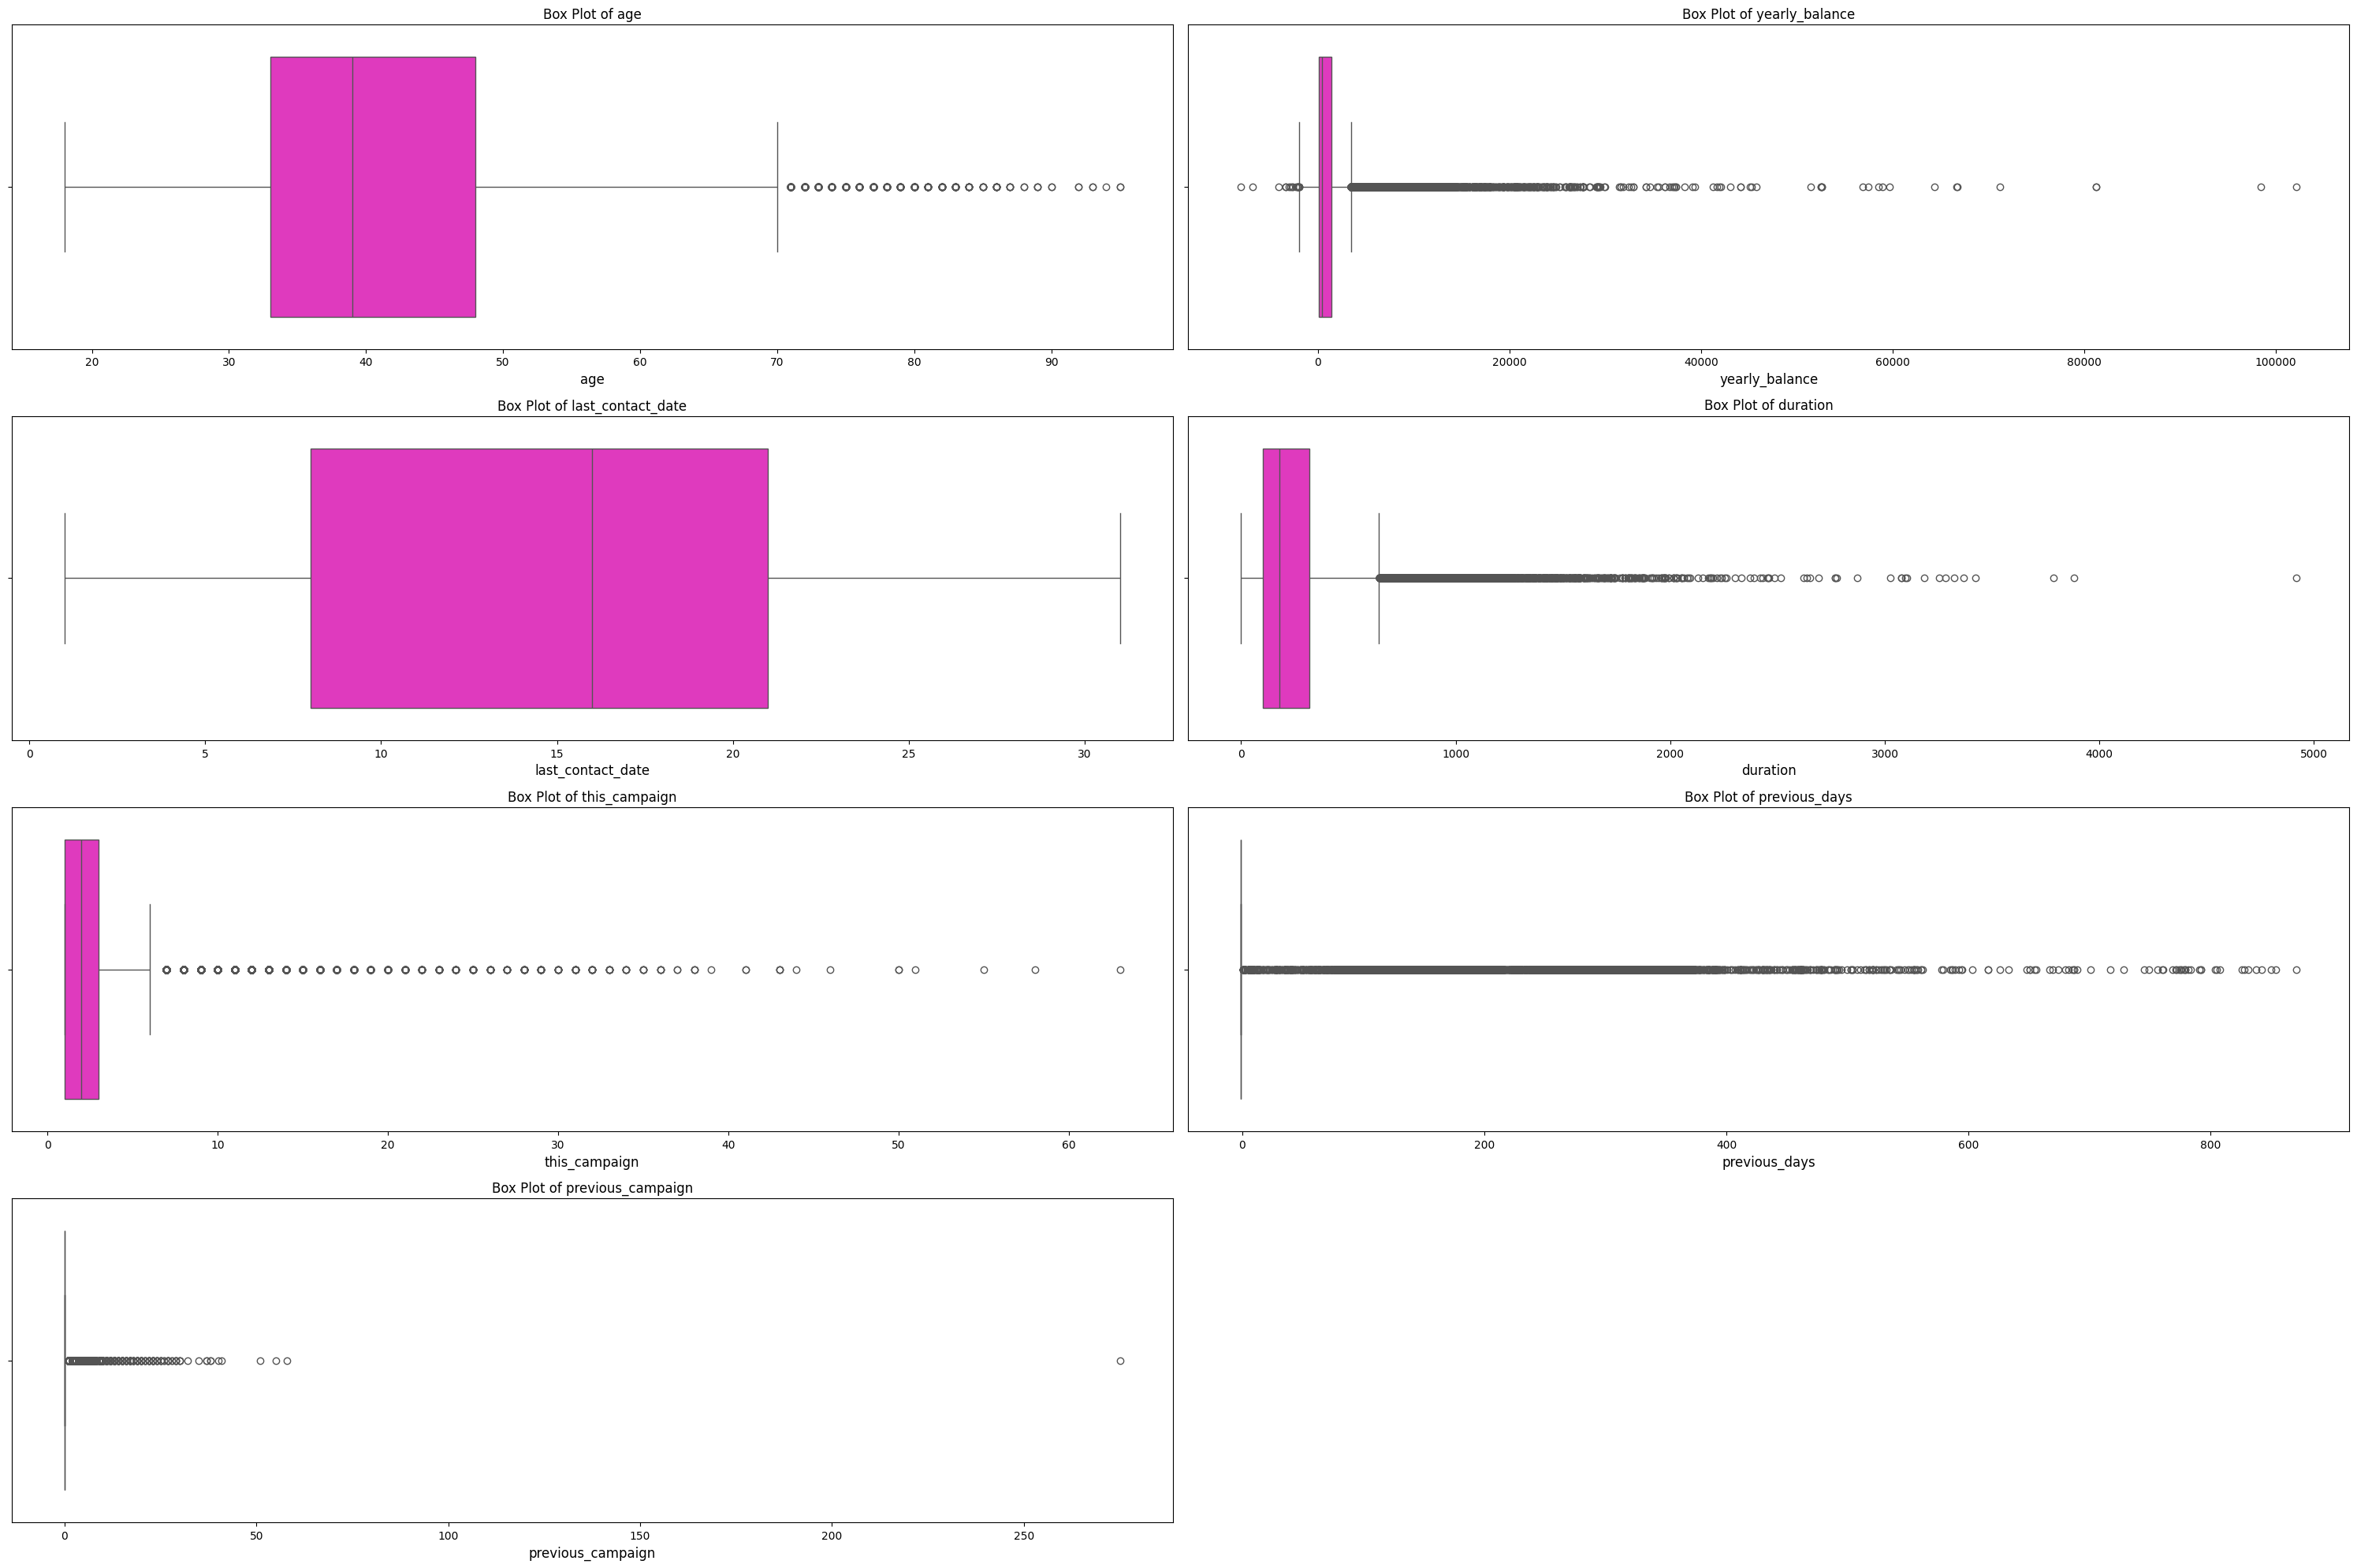

In [5]:
# Split columns by type 
num_cols = df.select_dtypes(include=['int64']).columns #numerical
cat_cols = df.select_dtypes(include=['object']).columns # categorical

# Create the subplots
fig, axes = plt.subplots(4, 2, figsize=(30,20)) #grid of 7 subplots 
axes = [ax for axes_rows in axes for ax in axes_rows]# flatten to 1d subplots

# Box plots uses the IQR methods to see the distribution and outlier
for i, col in enumerate(num_cols): 
    sns.boxplot(x=df[col],  ax=axes[i], color='#fa1fcf')
    axes[i].set_title(f'Box Plot of {col}', fontsize=12)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('', fontsize=12)

# Hide any unused subplots instead of showing a blank chart
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

**Observations: Numerical Data Types: Distribution and Outliers**
- Age: Most clients fall 30-60 years old.
- Yearly balance: It is **skewing** towards the right. A few clients have high balance that cause the mean to skew.
- Last contact date: no abnormalities.
- Duration: It also **skew** to the extreme right. Average less than 1000 seconds. Max over **4000 seconds**.
- This campaign: Mostly in the range of 1 to 5 calls. Why are clients being contacted **50+ times**. Is it aggressive marketing?
- Previous days: **Long tail**. Most clients have no prior contacts and a few contacted hundreds opf days before.
- Previous campaign: Mostly zero values totally no prior campaign interactions. Where else some had **100+** of previous contact.

**Categorical Data Types: Frequency**

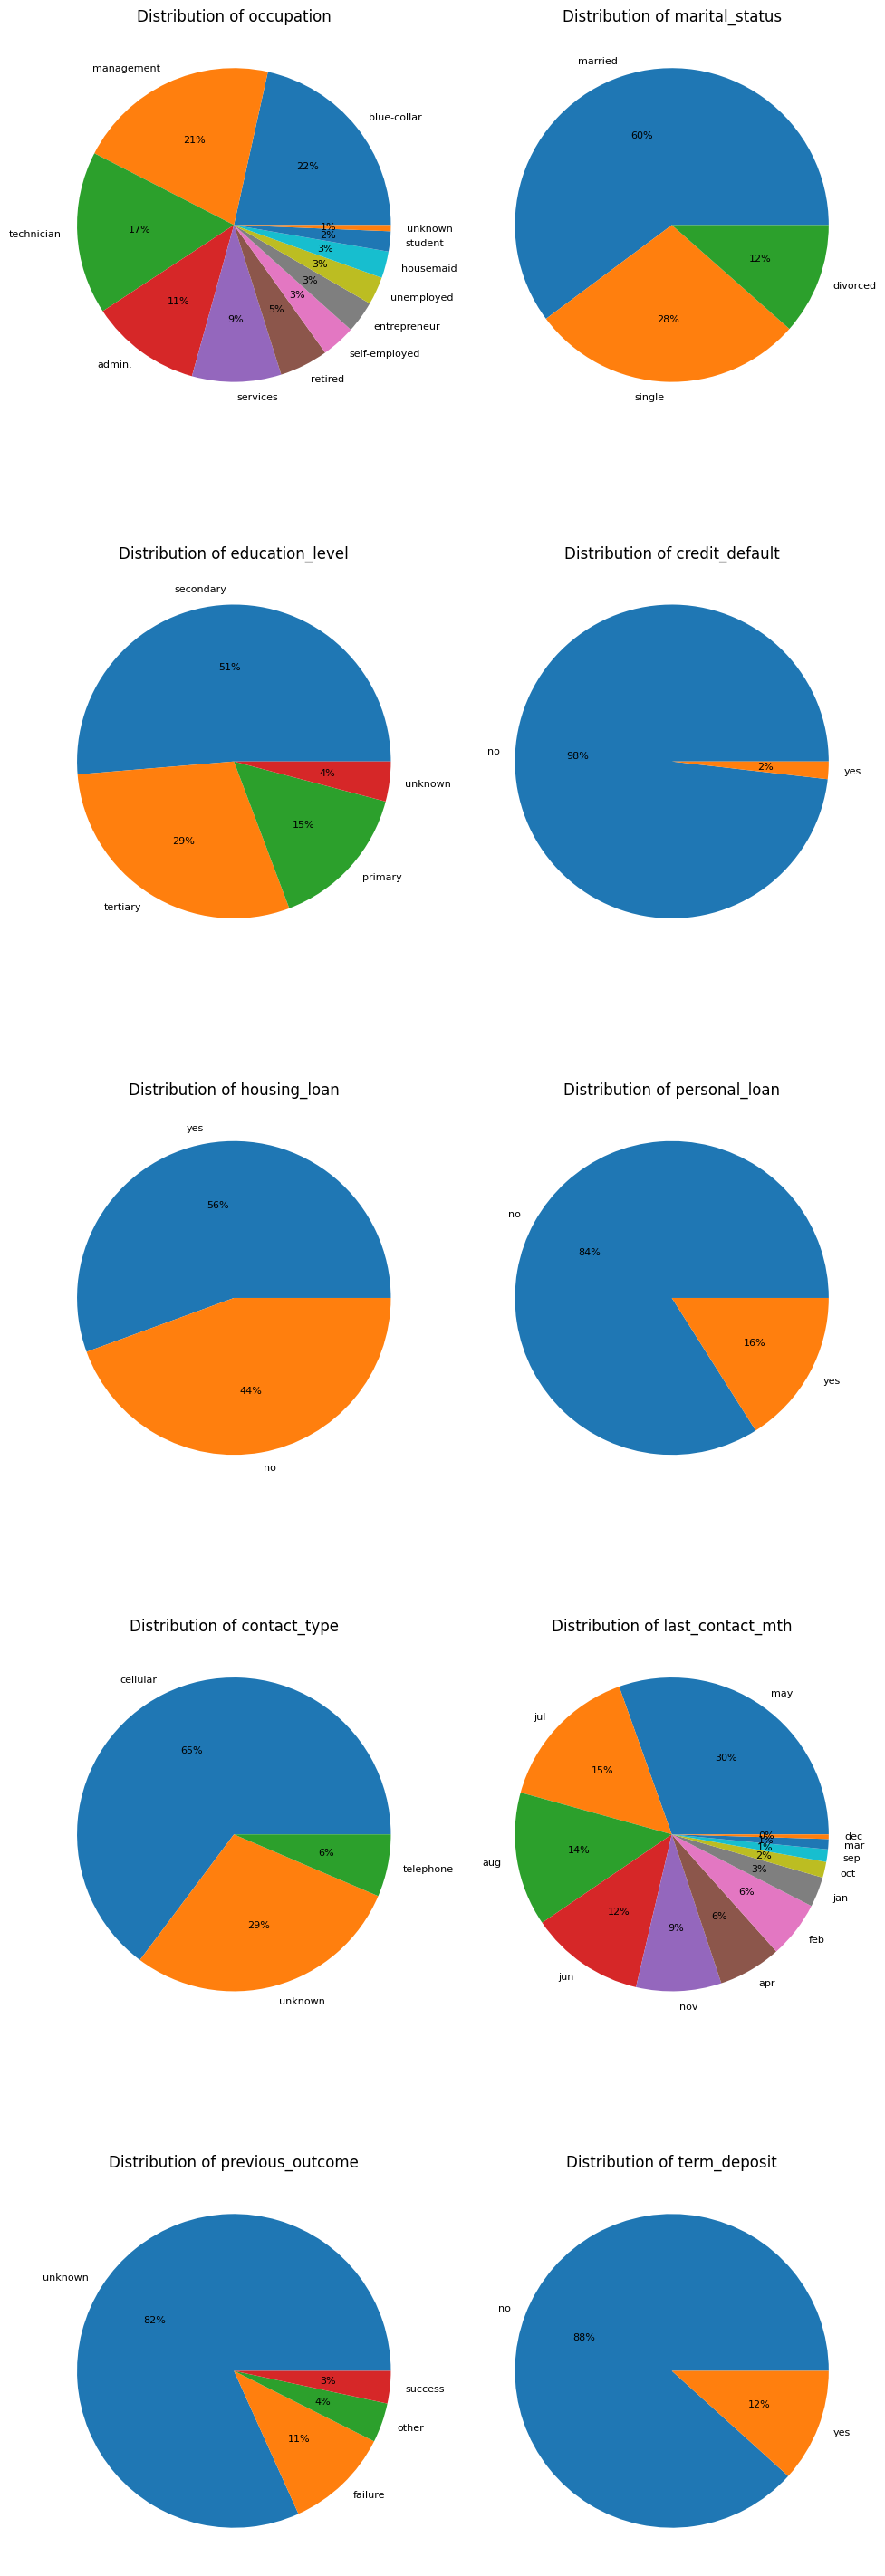

In [6]:
# Create the subplots
fig, axes = plt.subplots(5, 2, figsize=(10,30)) #grid of 10 subplots 
axes = [ax for axes_rows in axes for ax in axes_rows]# flatten to 1d subplots

# using i and c defining the numbers of count to loop iterates through the columns specified 
for i, c in enumerate(df[cat_cols]): 
    df[c].value_counts().plot.pie( 
                              ax=axes[i], 
                              title=f'Distribution of {c}', 
                              autopct='%.0f%%', 
                              fontsize=8)
    axes[i].set_ylabel('') #pie plot with unit of %


plt.tight_layout()
plt.show()

**Categorical Data Types: Most Frequent**

In [7]:
#the most frequent value for each categorical column
for col in cat_cols:
    mode_val = df[col].mode()[0]  # Get the most frequent value
    print(f"Mode of '{col}': {mode_val}")


Mode of 'occupation': blue-collar
Mode of 'marital_status': married
Mode of 'education_level': secondary
Mode of 'credit_default': no
Mode of 'housing_loan': yes
Mode of 'personal_loan': no
Mode of 'contact_type': cellular
Mode of 'last_contact_mth': may
Mode of 'previous_outcome': unknown
Mode of 'term_deposit': no


**Observations: Categorical Data Types: Frequency**
- Occupation: Most common blue-collar, management and technician.
- Marital status: Majority of the clients are married.
- Education: Majority of the client have secondary education.
- Credit default, housing loan and personal loan: Majority no Credit default, housing loan and personal loan.
- Contact type: Cellular.
- Last contact month: Mostly in **May** and low in mMarch, September and December.
- Previous outcome: Mostly had not been contacted before.
- Term deposit (Target): Mostly not subscribe.

<div style="
    background: linear-gradient(to right,rgb(246, 37, 156),rgb(175, 56, 244));
    padding: 5px;
    border-radius: 8px;
    box-shadow: 2px 2px 8px rgb(255, 255, 255);
">
  <h3 style="
      color: Black;
      font-size: 18px;
      font-weight: 800;
      font-family: 'Segoe UI', sans-serif;
      margin: 0;
  ">Bivariate Analysis</h3>
</div>

**Numerical vs Categorical (Target: Term Deposit)**

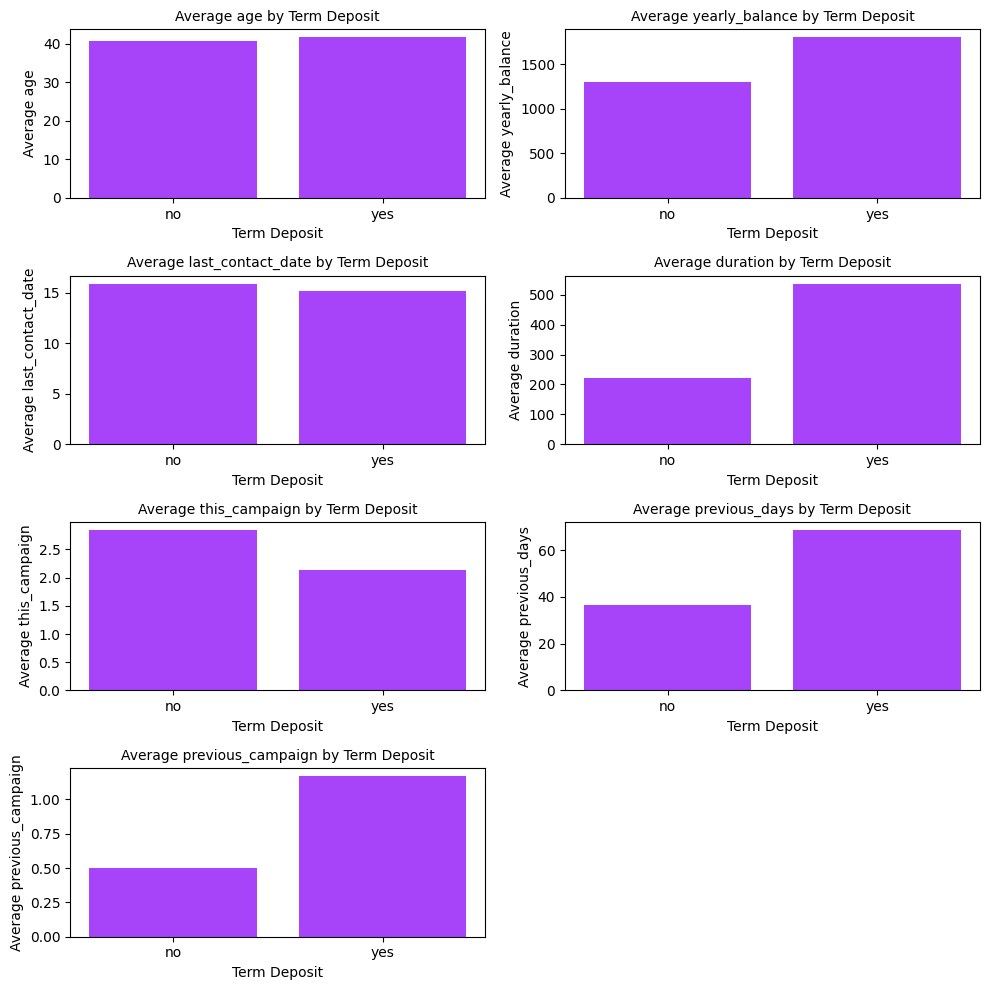

In [8]:
# Create the subplots
fig, axes = plt.subplots(4, 2, figsize=(10,10)) #grid of 8 subplots 
axes = [ax for axes_rows in axes for ax in axes_rows]# flatten to 1d subplots# Loop through numerical columns and plot bar chart of mean values grouped by term_deposit

# Loop through numerical columns
for i, col in enumerate(num_cols):
    group_means = df.groupby('term_deposit')[col].mean() #groupby target
    axes[i].bar(group_means.index, group_means.values, color='#a744fa') #calculates the mean/average value
    axes[i].set_title(f'Average {col} by Term Deposit',  fontsize=10)
    axes[i].set_xlabel('Term Deposit',  fontsize=10)
    axes[i].set_ylabel(f'Average {col}',  fontsize=10)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['no', 'yes'])

# Hide any unused subplots instead of showing a blank chart
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Observations: Numerical vs Categorical (Target: Term Deposit)**
- Age: It suggest that a slight more of older clients tends to subscribe
- Yearly balance: Subscribers had more savings.
- Last contact date: Both seems same, slight difference equals low impact on term deposit
- Duration: It suggest long duration, higher engagement much likely to subscribe
- This campaign: Subscribers were contacted less than those who subscribe
- Previous days: Average numbers of days are higher for subscribers than those who are non-subscribers
- Previous campaign: Majority of the subscribers participated in the previous campaign

**Numerical vs numerical**

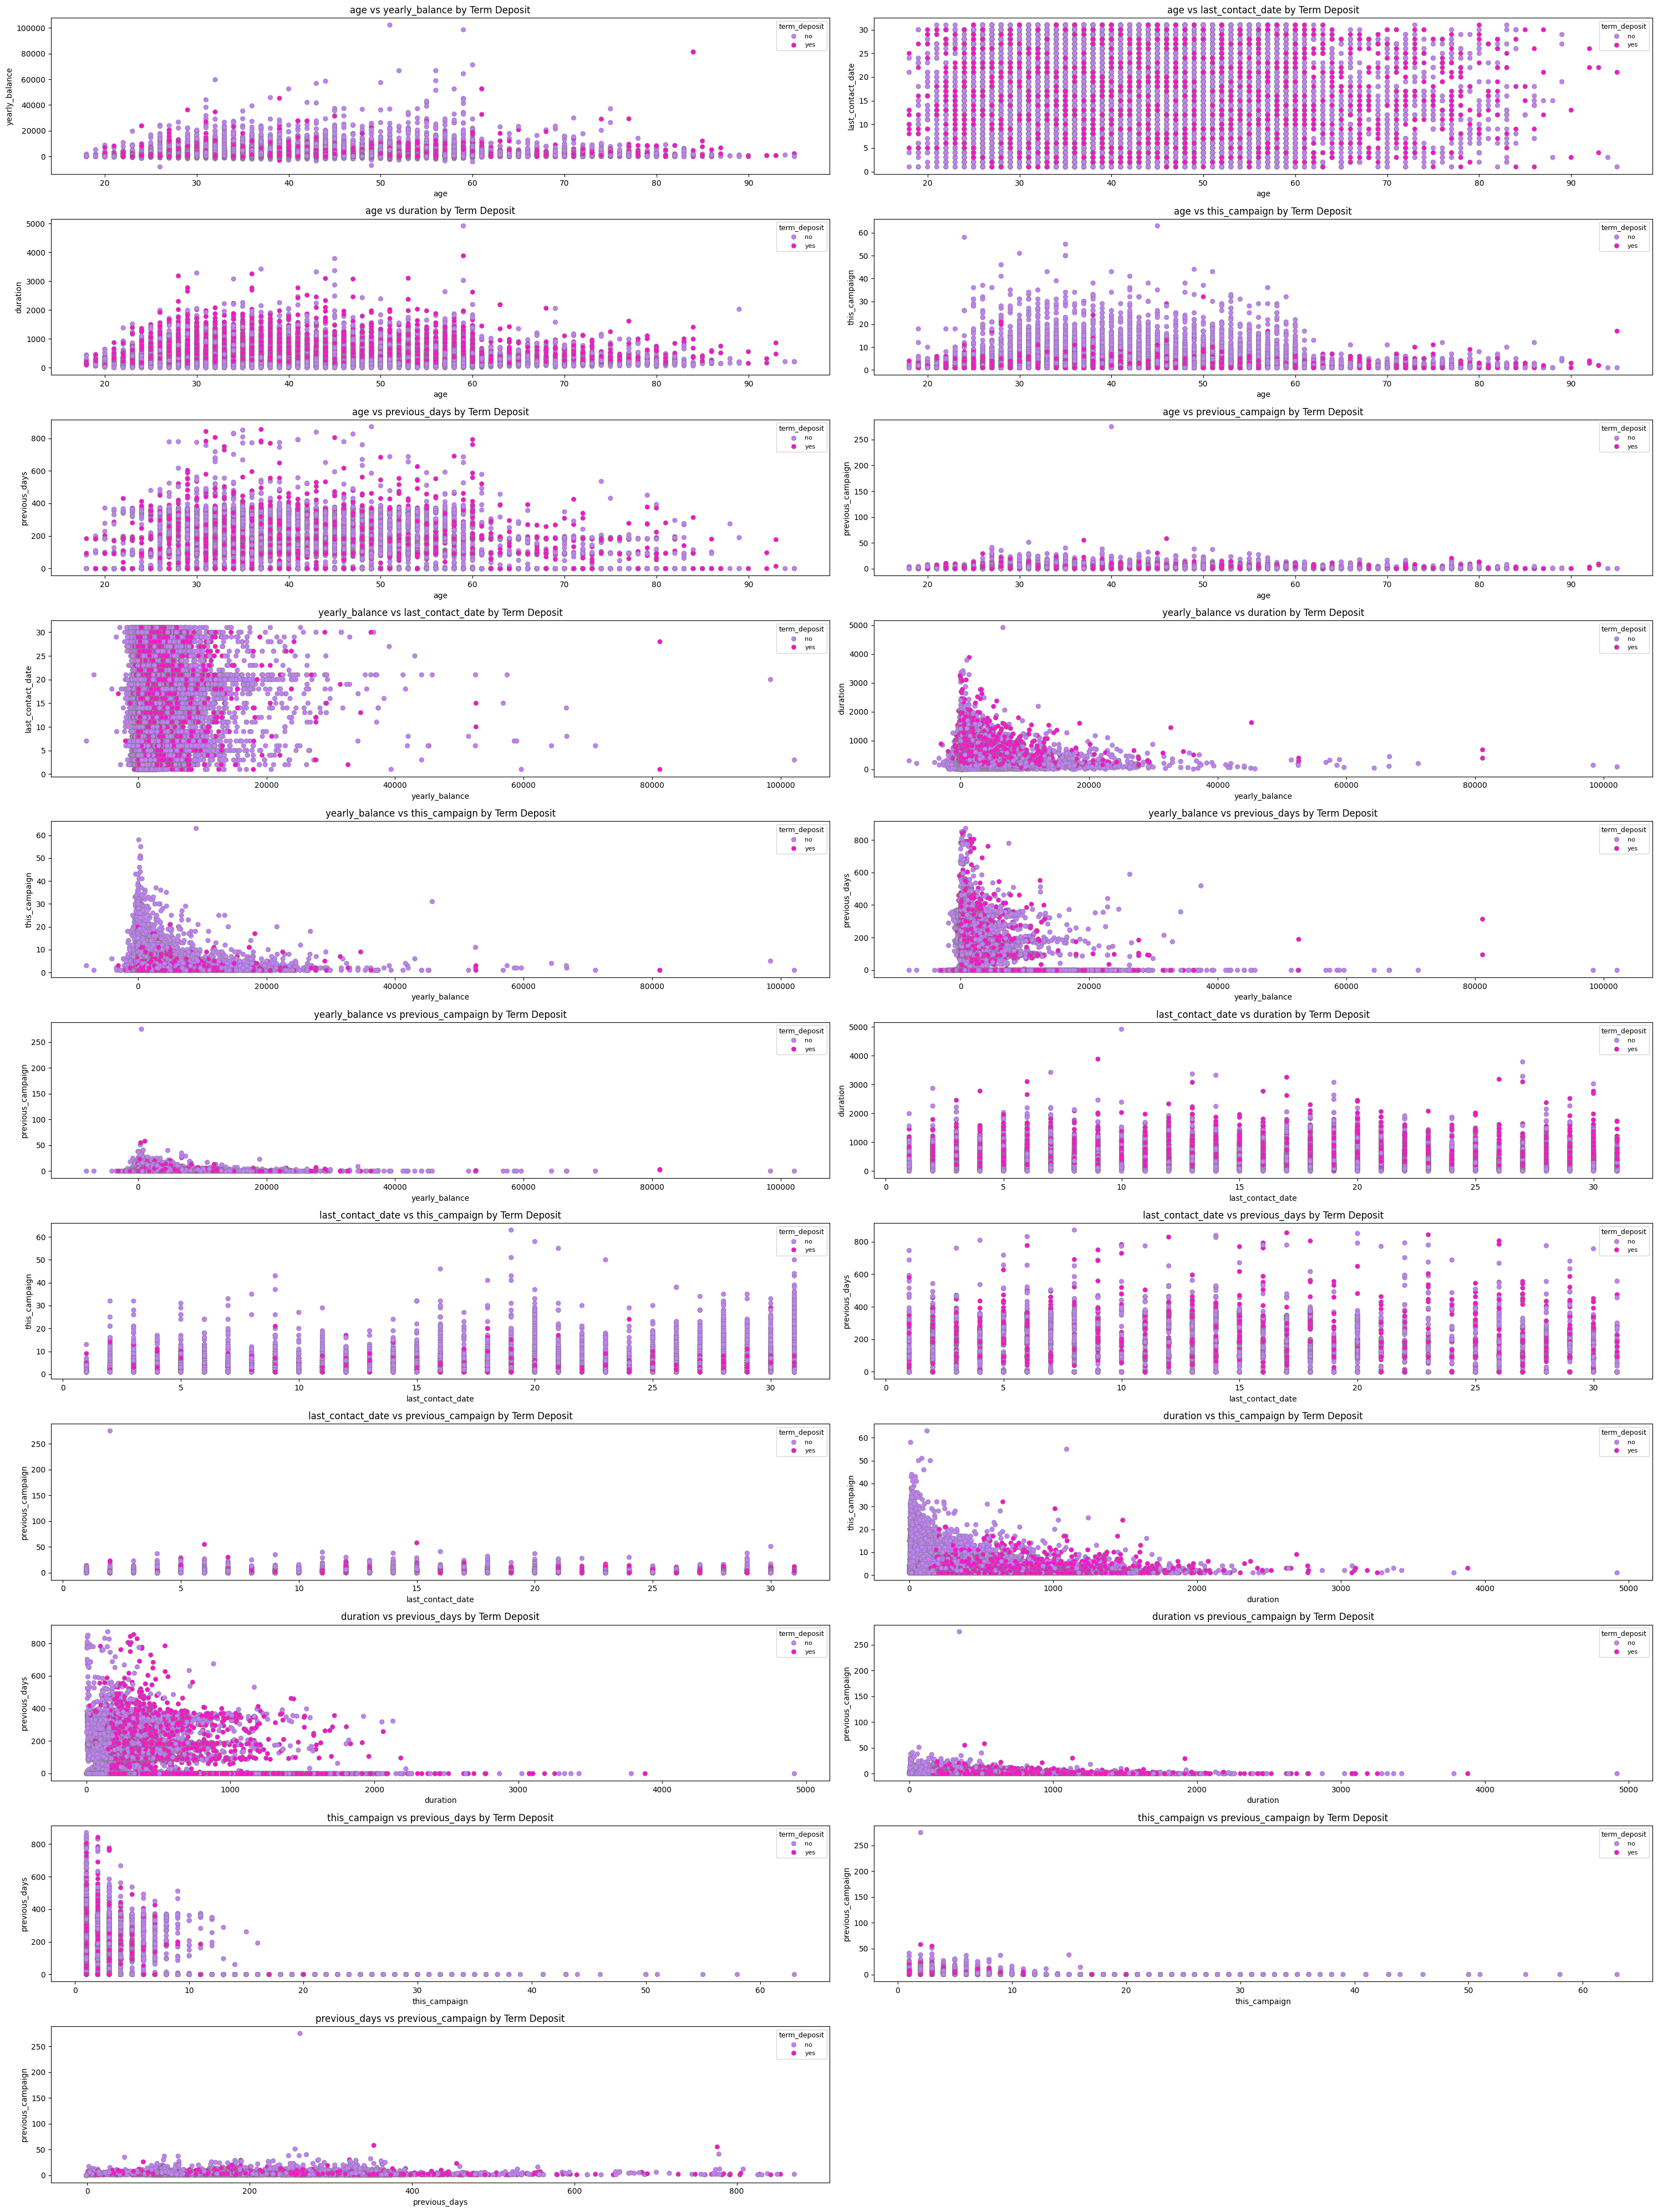

In [9]:
#Using itertools to pair the unique pairs and loop with it
num_pairs = list(itertools.combinations(num_cols, 2))

# Create the subplots
fig, axes = plt.subplots(11, 2, figsize=(30, 40))   #grid of 22 subplots 
axes = [ax for axes_rows in axes for ax in axes_rows]# flatten to 1d subplots

# Plot each pair as a scatter plot
for i, (x_col, y_col) in enumerate(num_pairs):
    if i >= len(axes):  # avoid index error if too many pairs
        break
    sns.scatterplot(
        data=df,
        x=x_col,
        y=y_col,
        hue='term_deposit',
        ax=axes[i],
        edgecolor='gray',
        palette={'yes': '#fc12ce', 'no': '#c27ffa'}
    )
    axes[i].set_title(f'{x_col} vs {y_col} by Term Deposit')
    axes[i].legend(title='term_deposit', fontsize=8, title_fontsize=9)
    
    # Remove unused axes (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Observation: Numerical vs numerical**
- Age:
    - Subscribed clients often had longer call durations.
    - No strong link between age and number of campaign contacts.
    - Higher previous_days among subscribers suggests longer gaps between contacts may help.
- Yearly Balance:
    - Higher balances correlate with longer calls and more subscriptions.
    - No clear pattern with campaign contact frequency.
    - Slight clustering of subscribers with mid-to-high previous_days.
- Duration:
    - Strong indicator of subscription—longer calls, especially with fewer contact attempts, show better outcomes.
    - More impact on subscription than most other variables.
- Campaign Contacts:
    - Most clients had few previous or current contacts.
    - No clear pattern between previous contacts and time since last contact.


**Categorical vs Categorical**

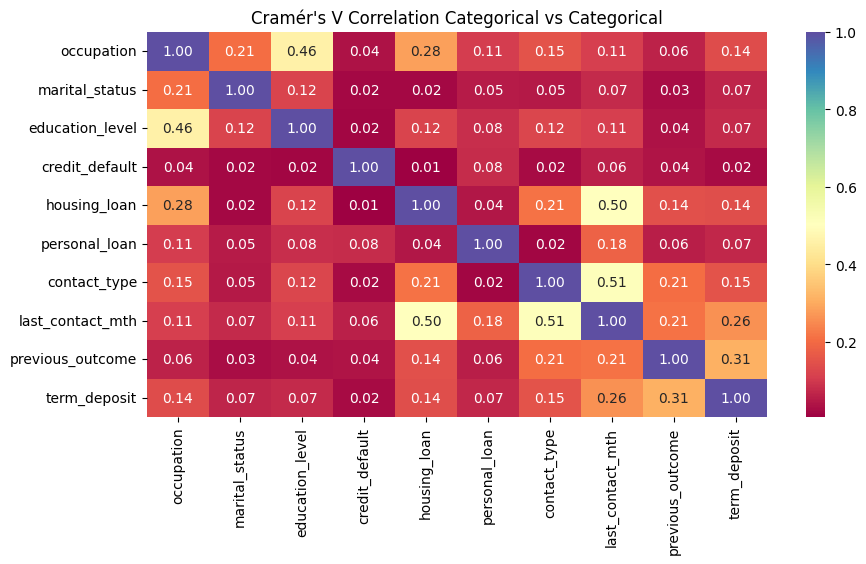

In [10]:
# Function to calculate Cramér's V Chi-squared test, 0 = no association 1 = perfect association
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y) #a contingency table for Chi-squared test 
    chi2 = chi2_contingency(confusion_matrix, correction=False)[0] #the Chi-squared test on 0 = no association 
    n = confusion_matrix.sum().sum() # total number of observations
    phi2 = chi2 / n
    r, k = confusion_matrix.shape #r = number of rows (categories of x) k = number of columns (categories of y)
    return np.sqrt(phi2 / min(k - 1, r - 1)) #final formula

# Selecting categorical columns
Cat_cols = df.select_dtypes(include=['object']).columns
cramers_results = pd.DataFrame(index=Cat_cols, columns=Cat_cols) 

for col1 in Cat_cols:
    for col2 in Cat_cols:
        cramers_results.loc[col1, col2] = cramers_v(df[col1], df[col2]) #Cramer's V results

# Convert to float for plotting
cramers_results = cramers_results.astype(float)

# Plot heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(cramers_results, annot=True, fmt=".2f", cmap='Spectral')
plt.title("Cramér's V Correlation Categorical vs Categorical")
plt.show()

**Observation: Categorical vs Categorical**
- Strongest:
    -   0.51: contact_type & last_contact_mth: cellular in May
    -   0.50: last_contact_mth & housing_loan: clients with housing loans were more frequently contacted during certain months
- Moderate: 
    -   0.46: education_level & occupation
    -   0.31: previous_outcome & term_deposit. Past campaign results is moderately predictive of current campaign outcomes.
- Weak or no relationship
    -   credit_default, personal_loan, marital_status and previous_campaign.

<div style="
    background: linear-gradient(to right,rgb(246, 37, 156),rgb(175, 56, 244));
    padding: 5px;
    border-radius: 8px;
    box-shadow: 2px 2px 8px rgb(255, 255, 255);
">
  <h3 style="
      color: Black;
      font-size: 18px;
      font-weight: 800;
      font-family: 'Segoe UI', sans-serif;
      margin: 0;
  ">Summary of Exploratory Data Analysis (EDA)</h3>
</div>

- Longer call durations and higher balances strongly correlate with subscriptions.
- Excessive contact attempts may reduce campaign effectiveness.
- Prior campaign success and longer gaps between contacts are linked to higher conversion.
- Most clients are new or unengaged; segmentation may improve targeting.
- Class imbalance and feature skewness must be addressed in preprocessing.

<div style="
    background: linear-gradient(to right,rgb(246, 37, 156),rgb(175, 56, 244));
    padding: 5px;
    border-radius: 8px;
    box-shadow: 2px 2px 8px rgb(255, 255, 255);
">
  <h3 style="
      color: Black;
      font-size: 18px;
      font-weight: 800;
      font-family: 'Segoe UI', sans-serif;
      margin: 0;
  ">Feature Engineering</h3>
</div>

**Steps**
1. One-hot encode categorical columns to numerical format for better modeling
2. Using robust scaler as there are few high outliers. To standardize numerical columns and prevent unfair weight. e.g duration <4000 seconds, Yearly balance (100,000) and previous days.
3. Splitting the data to train and test
4. Using SMOTE to treat the class imbalances. Balance the data before modeling.

In [11]:
#separate the target from df
y = df['term_deposit'].map({'no': 0, 'yes': 1})   # binary target

#drop the target column from df
df = df.drop(columns=['term_deposit'])

#redefining categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()

#one hot encoding to all categorical columns
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

#redefining num_cols from df_encoded
num_cols = df_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()

# scaling numerical columns
scaler = RobustScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

#Defining x
X = df_encoded

#train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)

#apply SMOTE to balance the training set
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# convert all to numerical
X_train_balanced = X_train_balanced.astype('float32')
X_test = X_test.astype('float32')

print("Before SMOTE 0 = did not subscribe/1 = subscribers:", y_train.value_counts())
print("After SMOTE  0 = did not subscribe/1 = subscribers:", y_train_balanced.value_counts())

Before SMOTE 0 = did not subscribe/1 = subscribers: term_deposit
0    27945
1     3702
Name: count, dtype: int64
After SMOTE  0 = did not subscribe/1 = subscribers: term_deposit
0    27945
1    27945
Name: count, dtype: int64


**Modeling Selection**
- To compare both performance and interpretability:
1. Logistic Regression: A reliable baseline that’s easy to explain.
2. Random Forest: Great for capturing non-linear patterns and reducing overfitting.
3. XGBoost: Known for strong performance on structured data.
4. ANN (Artificial Neural Network): Adds a deep learning option to explore more complex relationships.

In [12]:
# defining the evaluation function
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test) #1:yes or 0:no
    if hasattr(model, "predict_proba"): #predicted probabilities 
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test) #getting the predicted probabilities

    f1 = f1_score(y_test, y_pred, pos_label=1) #calculates F1 score for yes

    print(f"\n--- {name} ---") #for all the models
    print("F1 Score (Yes):", round(f1, 4))
    print("ROC AUC Score:", round(roc_auc_score(y_test, y_proba), 4)) #How well the model separates classes (1.0 = perfect, 0.5 = random)
    print(confusion_matrix(y_test, y_pred)) # true/false positives and negatives
    print(classification_report(y_test, y_pred)) #all in one. precision, recall, F1 score 

# defining the all the ML models into one
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42), #A linear model
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42), #A tree-based ensemble model 
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42) #	An optimized gradient boosting algorithm known for high accuracy.
}

# Train and evaluate all ML models
for name, model in models.items():
    model.fit(X_train_balanced, y_train_balanced)
    evaluate_model(name, model, X_test, y_test)

#4th a deep learning model: ANN
X_train_ann = X_train_balanced.astype("float32") #converting data types for tensorflow
X_test_ann = X_test.astype("float32")
y_train_ann = y_train_balanced.astype("int32")
y_test_ann = y_test.astype("int32")

#define ANN Model
ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_ann.shape[1],)), #first hidden layer with 64 neurons, relu= true if 1:yes
    Dropout(0.3), #prevents overfitting by randomly turning off 30%
    Dense(32, activation='relu'), #second hidden layer with 32 neurons, relu= true if 1:yes
    Dropout(0.3),
    Dense(1, activation='sigmoid') #sigmoid predicting whether a customer will subscribe (yes=1 or no=0)
])

ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']) #compile Adam optimizer and binary cross-entropy loss

#early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True) #Stops training early if validation loss doesnt improve 

#train ANN
ann_model.fit(
    X_train_ann, y_train_ann,
    validation_data=(X_test_ann, y_test_ann),
    epochs=50, #batch size 
    batch_size=32, #batch size 
    callbacks=[early_stop], 
    verbose=1)

#evaluate ANN
y_pred_ann = (ann_model.predict(X_test_ann) > 0.5).astype("int32")
y_proba_ann = ann_model.predict(X_test_ann)

#display the result
print("\n--- Artificial Neural Network ---")
print("F1 Score (Yes):", round(f1_score(y_test_ann, y_pred_ann), 4))
print("ROC AUC Score:", round(roc_auc_score(y_test_ann, y_proba_ann), 4))
print("Confusion Matrix:\n", confusion_matrix(y_test_ann, y_pred_ann))
print("Classification Report:\n", classification_report(y_test_ann, y_pred_ann))


--- Logistic Regression ---
F1 Score (Yes): 0.5362
ROC AUC Score: 0.8702
[[10632  1345]
 [  513  1074]]
              precision    recall  f1-score   support

           0       0.95      0.89      0.92     11977
           1       0.44      0.68      0.54      1587

    accuracy                           0.86     13564
   macro avg       0.70      0.78      0.73     13564
weighted avg       0.89      0.86      0.87     13564


--- Random Forest ---
F1 Score (Yes): 0.5691
ROC AUC Score: 0.922
[[11178   799]
 [  638   949]]
              precision    recall  f1-score   support

           0       0.95      0.93      0.94     11977
           1       0.54      0.60      0.57      1587

    accuracy                           0.89     13564
   macro avg       0.74      0.77      0.75     13564
weighted avg       0.90      0.89      0.90     13564


--- XGBoost ---
F1 Score (Yes): 0.5753
ROC AUC Score: 0.923
[[11328   649]
 [  684   903]]
              precision    recall  f1-score   suppo

**Hyperparameter Tuning**
- RandomizedSearchCV: Logistic Regression, Random Forest and XGBoost. Fast and high performance
- RandomizedSearchCV capture complex pattern



In [13]:
#f1 score, roc auc, confusion matrix and classification
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)
    f1 = f1_score(y_test, y_pred, pos_label=1)

    print(f"\n--- {name} ---")
    print("F1 Score (Yes):", round(f1, 4))
    print("ROC AUC Score:", round(roc_auc_score(y_test, y_proba), 4))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

#randomizedSearchCV best combination of parameters 
#randomizedSearchCV: Logistic Regression
log_reg_params = {'C': np.logspace(-2, 1, 10), 'solver': ['liblinear']}
log_reg_rand = RandomizedSearchCV(LogisticRegression(max_iter=1000, random_state=42), log_reg_params, n_iter=10, cv=3, scoring='f1', random_state=42)
log_reg_rand.fit(X_train_balanced, y_train_balanced)

#randomizedSearchCV - Random Forest
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]}
rf_rand = RandomizedSearchCV(RandomForestClassifier(random_state=42), rf_params, n_iter=10, cv=3, scoring='f1', random_state=42)
rf_rand.fit(X_train_balanced, y_train_balanced)

#randomizedSearchCV - XGBoost
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]}
xgb_rand = RandomizedSearchCV(XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42), xgb_params, n_iter=10, cv=3, scoring='f1', random_state=42)
xgb_rand.fit(X_train_balanced, y_train_balanced)

#defining tuned Models
models = {
    "Tuned Logistic Regression": log_reg_rand.best_estimator_, #best version
    "Tuned Random Forest": rf_rand.best_estimator_,
    "Tuned XGBoost": xgb_rand.best_estimator_}

#ANN
for name, model in models.items():
    evaluate_model(name, model, X_test, y_test)

X_train_ann = X_train_balanced.astype("float32")
X_test_ann = X_test.astype("float32")
y_train_ann = y_train_balanced.astype("int32")
y_test_ann = y_test.astype("int32")

ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_ann.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')]) #binary.


ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True) #to avoid overfitting

ann_model.fit(
    X_train_ann, y_train_ann,
    validation_data=(X_test_ann, y_test_ann),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1)

#evaluate ANN
y_pred_ann = (ann_model.predict(X_test_ann) > 0.5).astype("int32") #ensure numerical types
y_proba_ann = ann_model.predict(X_test_ann)

print("\n--- Artificial Neural Network ---")
print("F1 Score (Yes):", round(f1_score(y_test_ann, y_pred_ann), 4))
print("ROC AUC Score:", round(roc_auc_score(y_test_ann, y_proba_ann), 4))
print("Confusion Matrix:\n", confusion_matrix(y_test_ann, y_pred_ann))
print("Classification Report:\n", classification_report(y_test_ann, y_pred_ann))



--- Tuned Logistic Regression ---
F1 Score (Yes): 0.54
ROC AUC Score: 0.8748
Confusion Matrix:
 [[10617  1360]
 [  497  1090]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.89      0.92     11977
           1       0.44      0.69      0.54      1587

    accuracy                           0.86     13564
   macro avg       0.70      0.79      0.73     13564
weighted avg       0.90      0.86      0.88     13564


--- Tuned Random Forest ---
F1 Score (Yes): 0.5792
ROC AUC Score: 0.9235
Confusion Matrix:
 [[11121   856]
 [  591   996]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94     11977
           1       0.54      0.63      0.58      1587

    accuracy                           0.89     13564
   macro avg       0.74      0.78      0.76     13564
weighted avg       0.90      0.89      0.90     13564


--- Tuned XGBoost ---
F1 Score (Yes): 0.5917


**Observations**
- All models showed gains in F1 Score and ROC AUC after tuning.
- Logistic Regression: Slight improvement. 
- Random Forest: Improved recall and F1 Score 
- Artificial Neural Network (ANN): Improved well on recall  but lower on precision.
- XGBoost: maintained the highest accuracy and best balance of precision and recall.
- Using Tuned XGBoost


<div style="
    background: linear-gradient(to right,rgb(246, 37, 156),rgb(175, 56, 244));
    padding: 5px;
    border-radius: 8px;
    box-shadow: 2px 2px 8px rgb(255, 255, 255);
">
  <h3 style="
      color: Black;
      font-size: 18px;
      font-weight: 800;
      font-family: 'Segoe UI', sans-serif;
      margin: 0;
  ">Top 20 Features Predictors</h3>
</div>

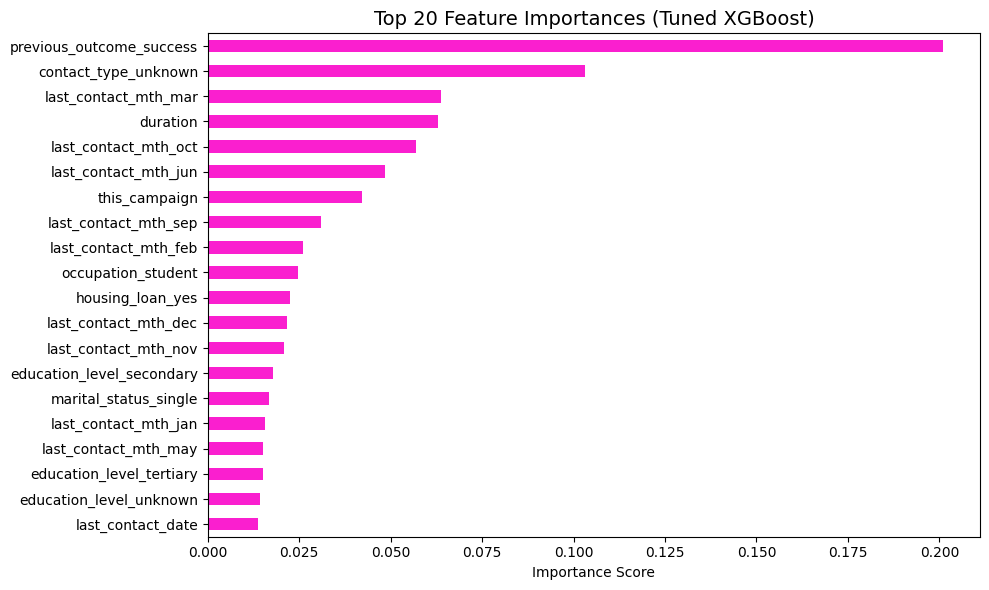

In [14]:
#defining trained XGBoost model
xgb = models["Tuned XGBoost"]

#defining feature importances these scores reflect how often
importances = xgb.feature_importances_
features = X_train_balanced.columns

#put into a list and sort it
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

# Top 20 features 
plt.figure(figsize=(10, 6))
feat_imp.head(20).plot(kind='barh', color='#fa1fcf') #bar plot
plt.title('Top 20 Feature Importances (Tuned XGBoost)', fontsize=14)
plt.gca().invert_yaxis()  # Most important feature on top
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


**Summary**
- The predictive analysis was successful based on both performance metrics and business applicability.
- XGBoost achieved strong scores of **90%** accuracy and **92.3%** ROC AUC

<div style="
    background: linear-gradient(to right,rgb(246, 37, 156),rgb(175, 56, 244));
    padding: 5px;
    border-radius: 8px;
    box-shadow: 2px 2px 8px rgb(255, 255, 255);
">
  <h3 style="
      color: Black;
      font-size: 18px;
      font-weight: 800;
      font-family: 'Segoe UI', sans-serif;
      margin: 0;
  ">Deployment XGBoost</h3>
</div>

In [15]:
#save XGBoost model
joblib.dump(xgb_rand.best_estimator_, "xgboost_model.pkl")

#save input features for dashboard
joblib.dump([
    "age",
    "yearly_balance",
    "last_contact_date",
    "duration",
    "this_campaign",
    "previous_days",
    "marital_status_married",
    "marital_status_single",
    "education_level_secondary",
    "education_level_tertiary",
    "education_level_unknown",
    "housing_loan_yes",
    "contact_type_unknown",
    "last_contact_mth_jan",
    "last_contact_mth_feb",
    "last_contact_mth_mar",
    "last_contact_mth_may",
    "last_contact_mth_jun",
    "last_contact_mth_jul",
    "last_contact_mth_aug",
    "last_contact_mth_sep",
    "last_contact_mth_oct",
    "last_contact_mth_nov",
    "last_contact_mth_dec",
    "previous_outcome_success"
], "input_features.pkl")

['input_features.pkl']

In [ ]:
pip freeze > requirements.txt